# Simulation of Brownian motion using discretized Langevin equation

Langevin's equation reads

$$\frac{\text{d}}{\text{d}t}v(t) = -\eta v(t) + \xi(t),$$

where $\xi(t)$ is the stochastic term, $\eta$ is friction coefficient and $v(t)$ denotes the velocity of the Brownian particle.
In the equations below, temperature will be denoted $T$, discrete time intervals $\Delta t$, mass of the particle $m$. Also note that the algorithms used origin from [1].

## Algorithm BD1

Discretised Langevin equation might be written as

$$v_{n+1} = (1-\eta \Delta t) v_n + \sqrt{\frac{2\eta k_B T \Delta t}{m}}\mathcal{G}_n$$

with $\mathcal{G}_n$ being Gaussian random number with zero mean, unit variance and no dependence on previous step.

**Note:** In the code below, we will be plotting the velocity in units of *thermal velocity* $v_{th} = \sqrt{k_BT/m}$ and time in units of relaxation time $\tau = 1/\eta$. This simplifies the whole calculation, because we can from the begining rescale to $v_{th} = 1$ and $\eta$ = 1, so that the only variable left is the initial velocity $v_0$ (now to be expressed as unitless multiple of $v_{th}$). The algorithm simplifies to
$$v_{n+1} = (1-\Delta t) v_n + \sqrt{2\Delta t}\,\mathcal{G}_n.$$
Last value to be inserted is the $\Delta t$, which is 1/resolution, where resolution means the number of points for evaluation of algorithm per one relaxation time $\tau$.

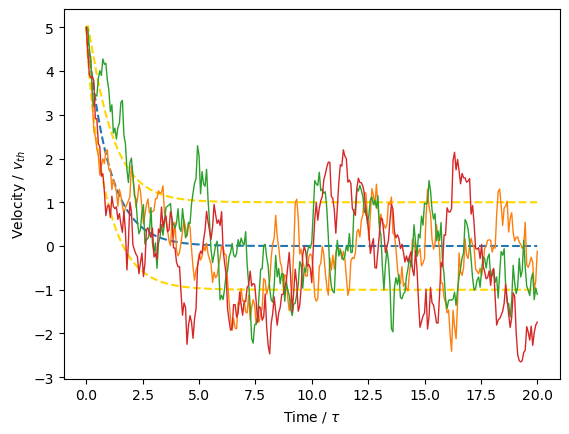

In [91]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42) # seed for reproducibility

# =================================
# Setup
# =================================
fig, ax = plt.subplots(1,1)

ax.set(xlabel=r"Time / $\tau$", ylabel=r"Velocity / $v_{th}$")

def SimulateBD1(t: np.ndarray, res: float, rng: np.random.Generator, Gn: np.ndarray = None) -> np.ndarray:
    if Gn is None:
        Gn = rng.standard_normal(len(t))
    
    vn = np.empty_like(t)
    vn[0] = v0
    
    for k in range(1,len(t)):
        vn[k] = (1-1/res)*vn[k-1] + np.sqrt(2/res)*Gn[k]

    return vn

# =================================
# Parameters of the simulation
# =================================
v0 = 5 # in multiples of vth = thermal velocity = sqrt(kB*T/m)
res = 15 # resolution
tfin = 20

# =================================
# Simulation
# =================================
t = np.linspace(0,tfin,tfin*res+1)

# First plot the expected value of speed
v_smooth = v0*np.exp(-t)
ax.plot(t,v_smooth,linestyle="--")

sigma = np.sqrt(1-np.exp(-2*t))
devup = v_smooth + sigma
devdown = v_smooth - sigma
ax.plot(t,devup, linestyle="--",color="gold")
ax.plot(t,devdown, linestyle="--",color="gold")

# Now do 3 simulations
for _ in range(3):
    v = SimulateBD1(t, res, rng)
    ax.plot(t,v,linewidth=1)

## Algorithm BD2

The recommended algorithm with better convergence is:

$$v_{n+1} = c_0 v_n + v_{th} \sqrt{1-c_0^2}\,\mathcal{G}_n,$$

where $c_0 = e^{-\eta \Delta t}$ and $v_{th} = \sqrt{k_BT/m}$. Again, $\mathcal{G}_n$ is Gaussian random variable with zero mean and unit variance uncorrelated in time (i.e. independent of previous steps).

**Note:** In the same manner as for BD1, the algorithm simplifies to
$$v_{n+1} = e^{-\Delta t} v_n + \sqrt{1-e^{-\Delta t}}\, \mathcal{G}_n.$$

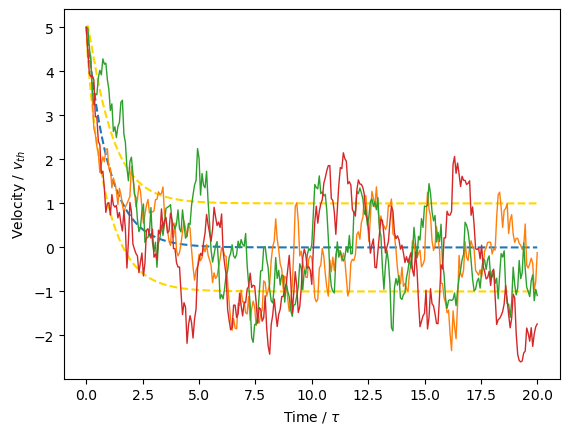

In [92]:
rng = np.random.default_rng(42) # seed for reproducibility

# =================================
# Setup
# =================================
fig, ax = plt.subplots(1,1)

ax.set(xlabel=r"Time / $\tau$", ylabel=r"Velocity / $v_{th}$")

c0 = np.exp(-1/res)
c1 = np.sqrt(1-c0**2)

def SimulateBD2(t: np.ndarray, rng: np.random.Generator, Gn: np.ndarray = None) -> np.ndarray:
    if Gn is None:
        Gn = rng.standard_normal(len(t))
    
    vn = np.empty_like(t)
    vn[0] = v0
    
    for k in range(1,len(t)):
        vn[k] = c0*vn[k-1] + c1*Gn[k]

    return vn

# =================================
# Simulation
# =================================
t = np.linspace(0,tfin,tfin*res+1)

# First plot the expected value of speed
v_smooth = v0*np.exp(-t)
ax.plot(t,v_smooth,linestyle="--")

sigma = np.sqrt(1-np.exp(-2*t))
devup = v_smooth + sigma
devdown = v_smooth - sigma
ax.plot(t,devup, linestyle="--",color="gold")
ax.plot(t,devdown, linestyle="--",color="gold")

# Now do 3 simulations
for _ in range(3):
    v = SimulateBD2(t, rng)
    ax.plot(t,v,linewidth=1)

You can check that the results for both simulations are the same - the difference of these two algorithms becomes visible for large discretisations $\Delta t$ (notice how BD1 can be obtained asymptotically from BD2 as $\eta \Delta t \to 0$).

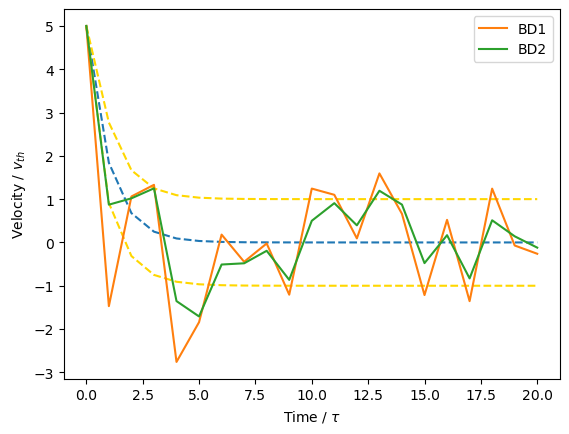

In [90]:
rng = np.random.default_rng(42) # seed for reproducibility

fig, ax = plt.subplots(1,1)
ax.set(xlabel=r"Time / $\tau$", ylabel=r"Velocity / $v_{th}$")

# Change the discretisation step
res = 1
c0 = np.exp(-1/res)
c1 = np.sqrt(1-c0**2)

t = np.linspace(0,tfin,tfin*res+1)

# To compare the two algorithms, we will use the same random values in both of them
Gn = rng.standard_normal(len(t))
v_bd1 = SimulateBD1(t, res, rng, Gn = Gn)
v_bd2 = SimulateBD2(t, rng, Gn = Gn)

# First plot the expected value and standard deviation from it
v_smooth = v0*np.exp(-t)
ax.plot(t,v_smooth,linestyle="--")

sigma = np.sqrt(1-np.exp(-2*t))
devup = v_smooth + sigma
devdown = v_smooth - sigma
ax.plot(t,devup, linestyle="--",color="gold")
ax.plot(t,devdown, linestyle="--",color="gold")

# Now plot the simulation results
ax.plot(t, v_bd1, label="BD1")
ax.plot(t, v_bd2, label="BD2")
ax.legend(loc = "best")

## References

[1] Wahnström, G. (2016, December 6). *Brownian dynamics: Lecture notes*. Chalmers University of Technology. [https://fy.chalmers.se/~tfsgw/CompPhys/lectures/BD_LectureNotes_161206.pdf](https://fy.chalmers.se/~tfsgw/CompPhys/lectures/BD_LectureNotes_161206.pdf)